# A simple notebook to get the all-sky images and corresponding segmentation masks from the kontas_2017 dataset

## Import Usepackages

In [91]:
import torch
import gc

# Force clear everything
torch.cuda.empty_cache()
gc.collect()

import cv2

import numpy as np
import random
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


from PIL import Image
from pathlib import Path

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

## Pre-defined Functions

In [92]:
# Image Augmentation: Rotation, Flip and Jitter

class CloudAugmentation:
    """Data augmentation for all-sky cloud images"""
    
    @staticmethod
    def random_rotate(image, mask):
        """Random rotation (90, 180, 270 degrees)"""
        k = np.random.randint(0, 4)  # ← np.random, not torch.randint
        if k > 0:
            image = np.rot90(image, k=k, axes=(0, 1))  # ← np.rot90, not torch.rot90
            mask = np.rot90(mask, k=k, axes=(0, 1))
        return image, mask
    
    @staticmethod
    def random_flip(image, mask):
        """Random horizontal/vertical flip"""
        if np.random.rand() > 0.5:  # ← np.random, not torch.rand
            image = np.fliplr(image)
            mask = np.fliplr(mask)
        if np.random.rand() > 0.5:
            image = np.flipud(image)
            mask = np.flipud(mask)
        return image, mask
    
    @staticmethod
    def color_jitter(image, brightness=0.4, contrast=0.4):
        """Adjust brightness and contrast"""
        img_float = image.astype(np.float32) / 255.0
        
        if np.random.rand() > 0.5:
            # Brightness
            factor = 1 + (np.random.rand() - 0.5) * 2 * brightness
            img_float = np.clip(img_float * factor, 0, 1)
        
        if np.random.rand() > 0.5:
            # Contrast
            mean = img_float.mean()
            factor = 1 + (np.random.rand() - 0.5) * 2 * contrast
            img_float = np.clip((img_float - mean) * factor + mean, 0, 1)
        
        return (img_float * 255).astype(np.uint8)
    
    @staticmethod
    def apply(image, mask, prob=0.5):
        """Apply random augmentations"""
        if np.random.rand() > prob:
            return image, mask
        
        image, mask = CloudAugmentation.random_rotate(image, mask)
        image, mask = CloudAugmentation.random_flip(image, mask)
        image = CloudAugmentation.color_jitter(image)
        
        return image, mask

In [93]:
def augment_dataset(images, masks, augment_factor=5):
    """
    Augment the dataset by creating multiple versions of each image.
    
    Args:
        images: List of numpy arrays (H, W, C)
        masks: List of numpy arrays (H, W)
        augment_factor: How many augmented versions per original image
    
    Returns:
        augmented_images, augmented_masks
    """
    aug_images = []
    aug_masks = []
    
    for img, mask in zip(images, masks):
        # Add original
        aug_images.append(img)
        aug_masks.append(mask)
        
        # Add augmented versions
        for _ in range(augment_factor - 1):
            aug_img, aug_mask = CloudAugmentation.apply(
                img.copy(), 
                mask.copy(), 
                prob=1.0  # Always apply augmentation
            )
            aug_images.append(aug_img)
            aug_masks.append(aug_mask)
    
    print(f"Original dataset: {len(images)} images")
    print(f"Augmented dataset: {len(aug_images)} images ({augment_factor}x)")
    
    return aug_images, aug_masks

In [94]:
def show_augmentations(images, masks, original_idx=0, augment_factor=5):
    """
    Show original image and its augmented versions
    
    Args:
        original_idx: Which original image to show (0, 1, 2, ...)
        augment_factor: How many versions per original
    """
    # Calculate indices
    start_idx = original_idx * augment_factor
    end_idx = start_idx + augment_factor
    
    # Get images and masks
    img_versions = images[start_idx:end_idx]
    mask_versions = masks[start_idx:end_idx]
    
    # Create plot
    fig, axes = plt.subplots(1, augment_factor, figsize=(4, 4))
    
    for i in range(augment_factor):
        # Show image
        axes[i].imshow(img_versions[i])
        if i == 0:
            axes[i].set_title('Original Image', fontsize=12, fontweight='bold')
        else:
            axes[i].set_title(f'Augmented {i}', fontsize=12)
        axes[i].axis('off')  
    
    plt.tight_layout()
    plt.show()

In [95]:
def extract_patches_grid(image,mask,patch_size=16):
    """
    Extract Patches.

    """

    # Convert tensor to numpy if needed
    if torch.is_tensor(image):
        image = image.cpu().numpy()
        # If tensor is (C, H, W), convert to (H, W, C)
        if image.ndim == 3 and image.shape[0] in [1, 3]:
            image = np.transpose(image, (1, 2, 0))
        # If normalized to [0, 1], scale to [0, 255]
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
    
    h, w = image.shape[:2]
    n_ph = h // patch_size   # patches per column (32)
    n_pw = w // patch_size   # patches per row    (32)
    n_patches_per_image = n_ph * n_pw


    images_patch = np.zeros((n_patches_per_image, patch_size, patch_size, 3), dtype=np.uint8)
    masks_patch  = np.zeros((n_patches_per_image, patch_size, patch_size),    dtype=np.int64)
    label_patch  = np.zeros( n_patches_per_image,                             dtype=np.int64)

    idx = 0
    for pr in range(n_ph):
        for pc in range(n_pw):
            r0, r1 = pr * patch_size, (pr + 1) * patch_size
            c0, c1 = pc * patch_size, (pc + 1) * patch_size
 
            img_patch  = image[r0:r1, c0:c1, :]   # (16, 16, C)
            mask_patch = mask[r0:r1, c0:c1]       # (16, 16)
 
            images_patch[idx]   = img_patch
            masks_patch[idx]    = mask_patch
            label_patch[idx]    = patch_label(mask_patch)
            idx += 1

    return label_patch, images_patch, masks_patch

In [96]:
def patch_label(mask_patch: np.ndarray) -> int:
    """Return the most frequent class in a mask patch."""
    values, counts = np.unique(mask_patch, return_counts=True)
    return int(values[np.argmax(counts)])

## Get the Data

In [97]:
# Define image and mask files
basePath = Path(r'kontas_2017')

# Append last_dir
image_path = basePath / "images"
mask_path = basePath / "seg_masks"

image_paths = sorted(Path(image_path).glob("*.jpg"))
mask_paths = sorted(Path(mask_path).glob("*.png"))

if len(image_paths) == len(mask_paths):
    print('Everything is fine: Number of images is equal to number of masks => ',len(image_paths))
else:
    print('Mismatch between images & masks')

Everything is fine: Number of images is equal to number of masks =>  770


In [98]:
# Get data

only3Classes = True # Use only class 0, 1, and 2 (where 2 contains the classes 2-5)

images = []
masks = []

for idx, img_path in enumerate(image_paths):
    image = Image.open(img_path).convert("RGB")
    image.load()
    images.append(image)

    mask = Image.open(mask_paths[idx])
    mask.load()

    if only3Classes:
        mask_remapped = np.copy(np.array(mask))
        mask_remapped[np.array(mask) >= 2] = 2  # Change only values >= 2 to 2
        mask = mask_remapped
        
    masks.append(mask)

# Data set
images = [np.array(img) for img in images]
masks = [np.array(mask) for mask in masks]

print("Number of images: ",len(images))

print(" - Size of a image: ",images[0].shape)
print(" - Size of a mask: ",masks[0].shape)

Number of images:  770
 - Size of a image:  (512, 512, 3)
 - Size of a mask:  (512, 512)


## Data Augmentation

In [99]:
images, masks = augment_dataset(images, masks, augment_factor=2) # augment factor defines how many augmented images per original image are generated

print("Number of images: ",len(images))
print("Number of masks: ",len(masks))
print(f" - Size of an image: {images[0].shape}")
print(" - Size of a mask: ",masks[0].shape)

Original dataset: 770 images
Augmented dataset: 1540 images (2x)
Number of images:  1540
Number of masks:  1540
 - Size of an image: (512, 512, 3)
 - Size of a mask:  (512, 512)


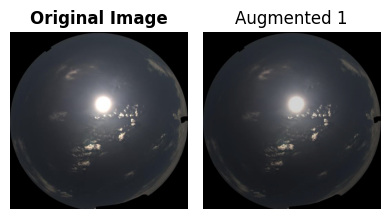

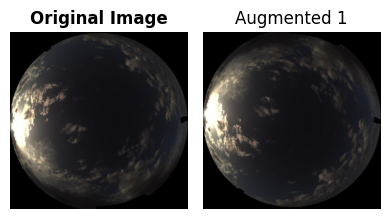

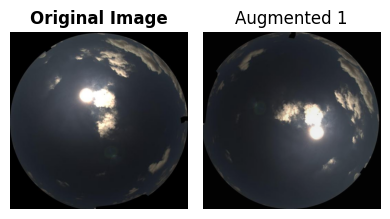

In [100]:
# Show augmentations for first original image
show_augmentations(images, masks, original_idx=3, augment_factor=2)

# Show augmentations for second original image
show_augmentations(images, masks, original_idx=100, augment_factor=2)

# Show augmentations for second original image
show_augmentations(images, masks, original_idx=500, augment_factor=2)

## Extract Patches

0/1540 done
100/1540 done
200/1540 done
300/1540 done
400/1540 done
500/1540 done
600/1540 done
700/1540 done
800/1540 done
900/1540 done
1000/1540 done
1100/1540 done
1200/1540 done
1300/1540 done
1400/1540 done
1500/1540 done
Done!


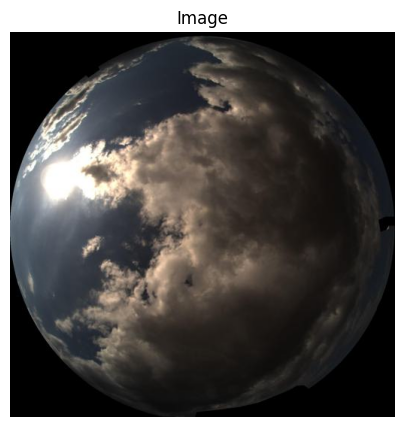

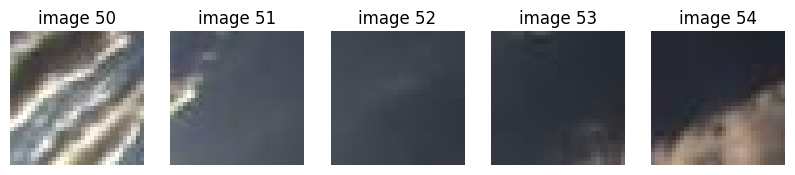

In [101]:
images_patch = []
masks_patch = []
labs_patch = []

for idx in range(len(images)):

    lab_patch, img_patch, mask_patch = extract_patches_grid(images[idx],masks[idx],32)

    if idx == 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(images[idx])
        ax.set_title("Image")
        ax.axis('off')

        fig, axes = plt.subplots(1, 5, figsize=(10, 8))  # adjust grid as needed
        for ii in range(5):
            axes[ii].imshow(img_patch[50+ii])
            axes[ii].set_title(f"image {50+ii}")
            axes[ii].axis('off')
        
    images_patch.append(img_patch)
    masks_patch.append(mask_patch)
    labs_patch.append(lab_patch)

    if idx % 100 == 0:
        print(f"{idx}/{len(images)} done")

print("Done!")

In [102]:
images_patch = np.vstack(images_patch)
masks_patch = np.vstack(masks_patch) 

labs_patch    = np.concatenate(labs_patch) # (n_images * 1024,)

print(images_patch.shape)  
print(masks_patch.shape)  
print(labs_patch.shape)     

(394240, 32, 32, 3)
(394240, 32, 32)
(394240,)


## Quantification of the data set

### Cloud coverage (per image)

In [103]:
cloud_fractions = []

for idx, image in enumerate(images):
    total_pixels = masks[idx].size-np.sum(masks[idx] == 0)
    cloud_pixels = np.sum(masks[idx] > 1)
    cloud_frac = (cloud_pixels / total_pixels)
    cloud_fractions.append(cloud_pixels / total_pixels)

cloud_fractions = np.array(cloud_fractions)


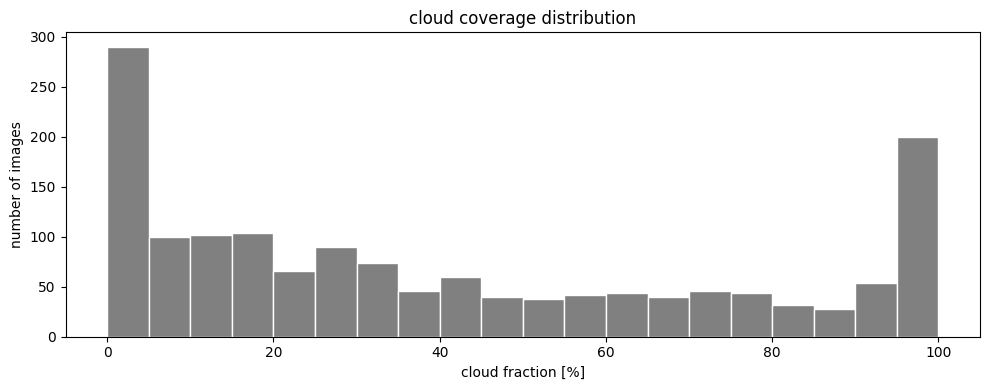

In [104]:
# Plot histogram
plt.figure(figsize=(10, 4))

plt.hist(cloud_fractions*100, bins=20, edgecolor="white", color="gray")
plt.xlabel("cloud fraction [%]")
plt.ylabel("number of images")
plt.title("cloud coverage distribution")
plt.tight_layout()
plt.savefig("cloud_coverage_histogram.png", dpi=150)
plt.show()

### Label Distribution

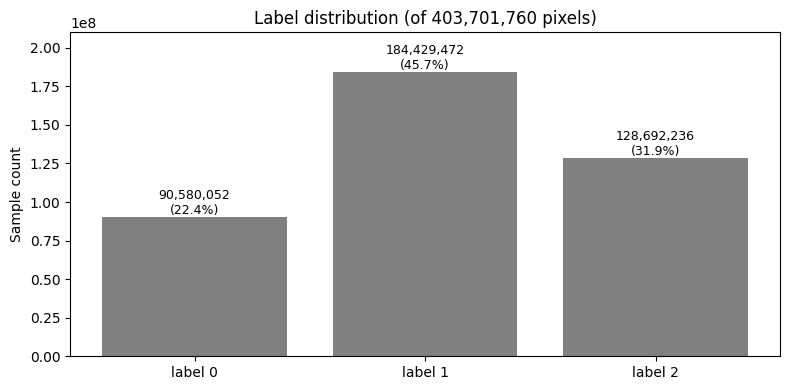

In [105]:
counts = np.bincount(np.array(masks).reshape(-1).astype(int))
classes = [f'label {i}' for i in range(len(counts))]

plt.figure(figsize=(8, 4))
plt.bar(classes, counts, color=['gray'])
plt.ylabel('Sample count')
plt.title(f'Label distribution (of {len(np.array(masks).reshape(-1).astype(int)):,} pixels)')
for i, c in enumerate(counts):
    plt.text(i, c + counts.max()*0.01, f'{c:,}\n({c/counts.sum()*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.ylim((0,210000000))
plt.show()


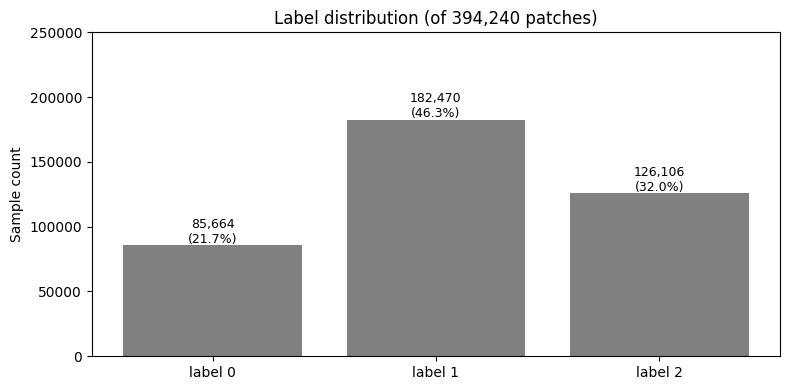

In [106]:
counts = np.bincount(labs_patch.astype(int))
classes = [f'label {i}' for i in range(len(counts))]

plt.figure(figsize=(8, 4))
plt.bar(classes, counts, color=['gray'])
plt.ylabel('Sample count')
plt.title(f'Label distribution (of {len(np.array(labs_patch).reshape(-1).astype(int)):,} patches)')
for i, c in enumerate(counts):
    plt.text(i, c + counts.max()*0.01, f'{c:,}\n({c/counts.sum()*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.ylim((0,250000))
plt.show()

## Store the data set

In [107]:

np.savez("dataset.npz", images=images, masks=masks)
np.savez("datasetPatch.npz", images_patch=images_patch, masks_patch=masks_patch,all_masks=labs_patch)